<h1 style="color:green;font-size:22px;">Function 6 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 6 is a **five-dimensional** black-box objective over the bounded domain $[0,1]^5$. Its analytical form and the interpretation of its coordinates are unknown. Starting from 20 initial observations, the objective is to **find the input configuration that maximises the observed value of Function 6** under a limited sequential-evaluation budget.

An illustrative analogy is the tuning of a machine-learning model with five normalised hyperparameters. A configuration can be evaluated and returns one performance score, but the relationship between the inputs and the score is not available analytically. This analogy is conceptual only: because the challenge does not disclose the meaning of the five coordinates, no domain-specific priors are imposed.

The 13 historical queries are organised into three strategy phases:

1. **Cartesian RBF-UCB exploration** (Weeks 1–3)
2. **Sobol Matérn-5/2 UCB transition** (Weeks 4–5)
3. **Local Sobol Matérn-5/2 EI refinement** (Weeks 6–13)

The final section evaluates query-budget performance, surrogate robustness and decision sensitivity.

In [1]:
# Standard libraries
import sys
import warnings
from pathlib import Path

# Numerical computing and data handling
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, RBF, WhiteKernel

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record

from src.search import (
    original_grid_blocks,
    exhaustive_cartesian_search,
    sobol_candidates,
    local_sobol_candidates)

from src.acquisition import (
    upper_confidence_bound,
    expected_improvement,
    decaying_kappa)

from src.plotting import (
    plot_pairwise_observations_2d,
    plot_sequential_query_performance)

from src.validation import (
    sequential_performance,
    kernel_choice_validation)

FUNCTION_ID = 6
DIMENSION = 5
INITIAL_OBSERVATIONS = 20
GRID_RESOLUTION = 25
LOCAL_RADIUS = np.array([0.12, 0.12, 0.12, 0.12, 0.08])
SOBOL_POWER = 14
SOBOL_SEED = 123

warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;">1. Initial observations</h1>

The experiment begins with 20 observations in five dimensions. Pairwise projections are useful for checking coverage, but they cannot reveal the complete geometry of the 5D response surface.

In [2]:
data = load_initial_data(FUNCTION_ID)
initial_inputs, initial_outputs = extract(data)

initial_best_idx = int(np.argmax(initial_outputs))

print(f"Initial observations: {len(initial_outputs)}")
print(f"Initial best: {initial_outputs[initial_best_idx]:.6f}")
print(f"Initial best location: {initial_inputs[initial_best_idx]}")
display(data)

Initial observations: 20
Initial best: -0.714265
Initial best location: [0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


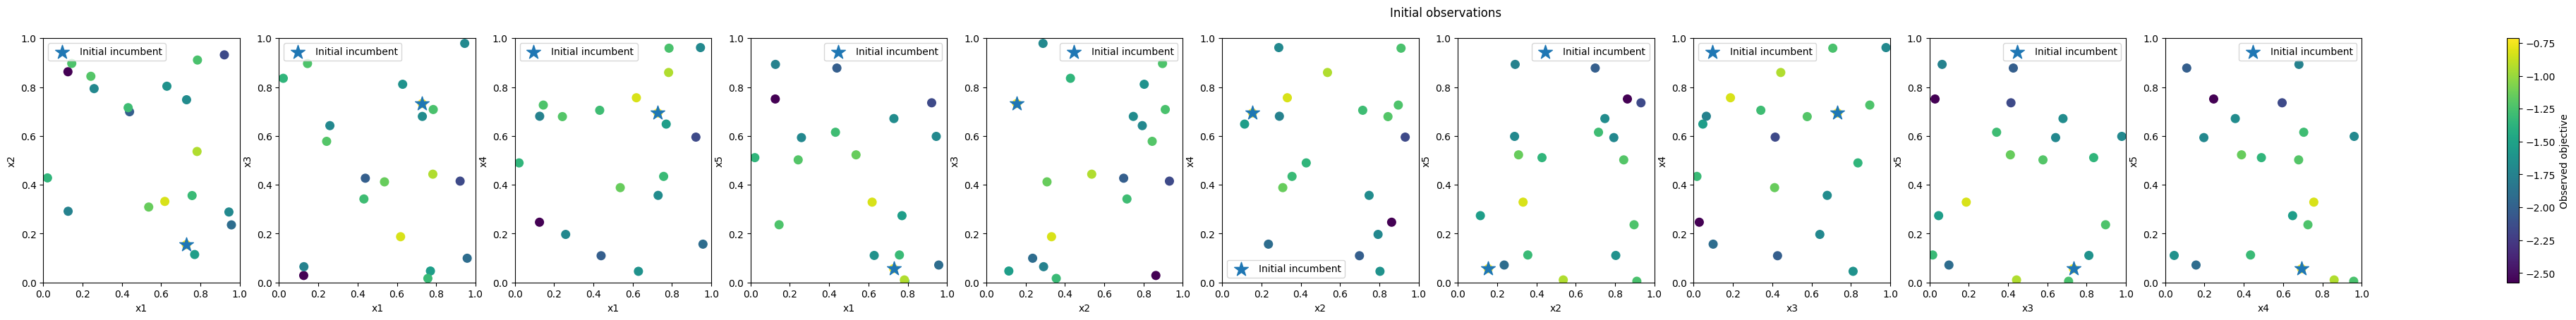

In [3]:
plot_pairwise_observations_2d(initial_inputs, initial_outputs)

**Initial interpretation.** The best starting response is approximately **-0.714265**. Twenty observations remain sparse relative to a five-dimensional domain, so the first phase keeps the search global and uses RBF-UCB rather than concentrating immediately around one observed point.

<h1 style="color:#0000CD;font-size:19px;">2. Phase 1: Cartesian RBF-UCB exploration (Weeks 1–3)</h1>

The first three queries reproduce the original global search:

- **Surrogate:** RBF GP, initial length scale $0.2$, optimised over the historical broad bounds;
- **Candidate set:** exact $25^5=9{,}765{,}625$ Cartesian grid;
- **Acquisition:** UCB with $\kappa=(1.5,\ 1.5,\ 2.50)$.


In [4]:
rbf_kernel = RBF(length_scale=0.20, length_scale_bounds=(1e-5, 1e5))+ WhiteKernel(noise_level=1e-6)
phase_1_kappa_schedule = {1: 1.50, 2: 1.50, 3: 2.50}
phase_1_rows = []

for week, kappa in phase_1_kappa_schedule.items():

    current_inputs, current_outputs = extract(data)
    previous_best = float(current_outputs.max())

    gp = GaussianProcessRegressor(kernel=rbf_kernel,alpha=1e-10,normalize_y=True)
    gp.fit(current_inputs, current_outputs)

    search = exhaustive_cartesian_search(
        gp,
        dimension=DIMENSION,
        resolution=GRID_RESOLUTION,
        kappa=kappa,
        compute_ucb=True)

    proposed = search["ucb_point"]
    recorded, observed_y = historical_record(FUNCTION_ID, week)
    matches_record = np.allclose(proposed, recorded, atol=5e-6)

    if not matches_record:
        warnings.warn( f"Week {week}: recomputed UCB candidate does not match " 
                       "the historical query.", RuntimeWarning)

    phase_1_rows.append({
        "week": week,
        "kappa": kappa,
        "candidate": np.round(proposed, 6).tolist(),
        "recorded_query": np.round(recorded, 6).tolist(),
        "matches_record": matches_record,
        "observed_y": observed_y,
        "previous_incumbent": previous_best,
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, recorded, observed_y)

phase_1_history = pd.DataFrame(phase_1_rows)
display(phase_1_history.style.set_properties(
        subset=["candidate", "recorded_query"],
        **{"white-space": "nowrap"}))

Point added!
Point added!
Point added!


,week,kappa,candidate,recorded_query,matches_record,observed_y,previous_incumbent,improved_incumbent
0,1,1.500000,"[0.375, 0.333333, 0.5, 0.75, 0.125]","[0.375, 0.333333, 0.5, 0.75, 0.125]",True,-0.265439,-0.714265,True
1,2,1.500000,"[0.25, 0.458333, 0.208333, 0.791667, 0.0]","[0.25, 0.458333, 0.208333, 0.791667, 0.0]",True,-0.901414,-0.265439,False
2,3,2.500000,"[0.291667, 0.041667, 0.666667, 1.0, 0.208333]","[0.291667, 0.041667, 0.666667, 1.0, 0.208333]",True,-0.801380,-0.265439,False


**Phase result and transition.** Week 1 improves the incumbent from approximately **-0.714265** to **-0.265439**; Weeks 2 and 3 do not improve it. The $25^5$ grid already requires almost 9.8 million acquisition evaluations while providing only 25 levels per coordinate. The next phase therefore changes both candidate design and surrogate smoothness rather than simply increasing Cartesian resolution.

<h1 style="color:#0000CD;font-size:19px;">3. Phase 2: Sobol Matérn-5/2 UCB transition (Weeks 4–5)</h1>

Phase 2 replaces the Cartesian RBF search with a Sobol/Matérn-5/2 UCB framework, first globally and then locally around the incumbent.

- **Week 4:** global Sobol search with $2^{14}=16{,}384$ candidates and UCB with $\kappa=2.50$.
- **Week 5:** local Sobol search within radius $(0.12,\ 0.12,\ 0.12,\ 0.12,\ 0.08)$, using $2^{14}$ candidates. EI with $\xi=0.005$ is retained as a diagnostic, while UCB remains the selected acquisition.

In [5]:
phase_2_transition_rows = []

# Week 4: global Sobol / Matérn UCB
current_inputs, current_outputs = extract(data)
previous_best = float(current_outputs.max())

week_4_kernel = Matern(length_scale=np.full(DIMENSION, 0.20), nu=2.5)+ WhiteKernel(noise_level=1e-5)
week_4_candidates = sobol_candidates(dimension=DIMENSION, power=SOBOL_POWER, seed=RANDOM_SEED)
week_4_gp = GaussianProcessRegressor(kernel=week_4_kernel, alpha=1e-10, normalize_y=True)
week_4_gp.fit(current_inputs, current_outputs)
mean, std = week_4_gp.predict(week_4_candidates, return_std=True)
week_4_ucb = upper_confidence_bound(mean, std, kappa=2.50)
week_4_selected = week_4_candidates[int(np.argmax(week_4_ucb))]

recorded, observed_y = historical_record(FUNCTION_ID, 4)
matches_record = np.allclose(week_4_selected, recorded, atol=5e-6)

phase_2_transition_rows.append({
    "week": 4,
    "scope": "Global",
    "candidate_design": "Sobol 2^14",
    "selected_acquisition": "UCB",
    "candidate": np.round(week_4_selected, 6).tolist(),
    "recorded_query": np.round(recorded, 6).tolist(),
    "matches_record": matches_record,
    "observed_y": observed_y,
    "improved_incumbent": observed_y > previous_best})

if not matches_record:
    warnings.warn(
        "Week 4: recomputed Sobol/Matérn UCB candidate does not "
        "match the historical query.", RuntimeWarning)

data = update_data(data, recorded, observed_y)

# Week 5: local Sobol / Matérn UCB with EI diagnostic
current_inputs, current_outputs = extract(data)
incumbent_idx = int(np.argmax(current_outputs))
incumbent_x = current_inputs[incumbent_idx].copy()
incumbent_y = float(current_outputs[incumbent_idx])

week_5_candidates, _, _ = local_sobol_candidates(
    incumbent_x,
    LOCAL_RADIUS,
    current_inputs,
    power=SOBOL_POWER,
    seed=SOBOL_SEED,
    min_distance=0.05)

local_kernel = (ConstantKernel(1.0, (1e-3, 1e3))* Matern(length_scale=np.full(DIMENSION, 0.20),
                                                        length_scale_bounds=(1e-2, 3.0),
                                                        nu=2.5)
               + WhiteKernel(noise_level=1e-6,noise_level_bounds=(1e-8, 1e-2)))

week_5_gp = GaussianProcessRegressor(
    kernel=local_kernel,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=12,
    random_state=RANDOM_SEED)

week_5_gp.fit(current_inputs, current_outputs)

mean, std = week_5_gp.predict(week_5_candidates, return_std=True)
week_5_ei = expected_improvement( mean, std, best=incumbent_y, xi=0.005)
week_5_ucb = upper_confidence_bound(mean, std, kappa=decaying_kappa(5))

ei_candidate = week_5_candidates[int(np.argmax(week_5_ei))]
ucb_candidate = week_5_candidates[int(np.argmax(week_5_ucb))]
week_5_selected = ucb_candidate

recorded, observed_y = historical_record(FUNCTION_ID, 5)
matches_record = np.allclose(week_5_selected, recorded, atol=5e-6)

phase_2_transition_rows.append({
    "week": 5,
    "scope": "Local",
    "candidate_design": "Sobol 2^14",
    "selected_acquisition": "UCB",
    "candidate": np.round(week_5_selected, 6).tolist(),
    "recorded_query": np.round(recorded, 6).tolist(),
    "matches_record": matches_record,
    "EI_UCB_distance": float(np.linalg.norm(ei_candidate - ucb_candidate)),
    "observed_y": observed_y,
    "improved_incumbent": observed_y > incumbent_y})

if not matches_record:
    warnings.warn(
        "Week 5: selected local UCB candidate does not match "
        "the historical query.",
        RuntimeWarning)

data = update_data(data, recorded, observed_y)

phase_2_history = pd.DataFrame(phase_2_transition_rows)
display(phase_2_history.style.set_properties(
        subset=["candidate", "recorded_query"],
        **{"white-space": "nowrap"}))

Point added!
Point added!


,week,scope,candidate_design,selected_acquisition,candidate,recorded_query,matches_record,observed_y,improved_incumbent,EI_UCB_distance
0,4,Global,Sobol 2^14,UCB,"[0.441619, 0.448046, 0.851877, 0.854748, 0.028702]","[0.441619, 0.448046, 0.851877, 0.854748, 0.028702]",True,-0.441430,False,nan
1,5,Local,Sobol 2^14,UCB,"[0.490337, 0.236686, 0.544983, 0.723086, 0.046093]","[0.490337, 0.236686, 0.544983, 0.723086, 0.046093]",True,-0.437764,False,0.072190


**Phase result.** Week 4 establishes the scalable global candidate design; Week 5 is the first local application of that design. Neither query improves the Week 1 incumbent, but together they complete the methodological move from a full tensor grid toward low-discrepancy Matérn-based refinement. Treating them as separate phases overstates the break between two consecutive parts of the same transition.

<h1 style="color:#0000CD;font-size:19px;">4. Phase 3: Local Sobol Matérn-5/2 EI refinement (Weeks 6–13)</h1>

From Week 6 onward the local candidate mechanism remains fixed:

- local radius $(0.12,\ 0.12,\ 0.12,\ 0.12,\ 0.08)$;
- $2^{14}$ scrambled Sobol candidates, seed 123;
- Matérn-5/2 GP with ARD length scales and 12 optimiser restarts;
- minimum distance $0.001$ from existing observations;
- EI with $\xi=0.001$ selects the query;
- UCB with $\kappa=2.5/\sqrt{\text{week}}$ is retained as a diagnostic.

The original Week 8 notebook contains a proposal/record discrepancy. The acquisition output proposed
$(0.425409,\ 0.367837,\ 0.742437,\ 0.703932,\ 0.203236)$,
whereas the evaluated record contains
$(0.425409,\ 0.367837,\ 0.367837,\ 0.703932,\ 0.203236)$.
The evaluated record remains the source of truth for every later GP fit.

In [6]:
phase_3_local_rows = []

for week in range(6, 14):
    current_inputs, current_outputs = extract(data)
    incumbent_idx = int(np.argmax(current_outputs))
    incumbent_x = current_inputs[incumbent_idx].copy()
    incumbent_y = float(current_outputs[incumbent_idx])

    candidates, _, _ = local_sobol_candidates(
        incumbent_x,
        LOCAL_RADIUS,
        current_inputs,
        power=SOBOL_POWER,
        seed=SOBOL_SEED,
        min_distance=0.001)

    gp = GaussianProcessRegressor(
        kernel=local_kernel,
        alpha=1e-10,
        normalize_y=True,
        n_restarts_optimizer=12,
        random_state=RANDOM_SEED)
    
    gp.fit(current_inputs, current_outputs)
    mean, std = gp.predict(candidates, return_std=True)

    ei = expected_improvement(mean, std, best=incumbent_y,xi=0.001)
    ucb = upper_confidence_bound(mean, std, kappa=decaying_kappa(week))

    ei_candidate = candidates[int(np.argmax(ei))]
    ucb_candidate = candidates[int(np.argmax(ucb))]
    recorded, observed_y = historical_record(FUNCTION_ID, week)

    matches_record = np.allclose(ei_candidate, recorded, atol=5e-6)

    if not matches_record:
        warnings.warn(
            f"Week {week}: recomputed EI proposal differs from the "
            "historical evaluated point; the historical record is retained.",
            RuntimeWarning)

    phase_3_local_rows.append({
        "week": week,
        "selected_acquisition": "EI",
        "EI_candidate": np.round(ei_candidate, 6).tolist(),
        "UCB_candidate": np.round(ucb_candidate, 6).tolist(),
        "recorded_query": np.round(recorded, 6).tolist(),
        "EI_UCB_distance": float(np.linalg.norm(ei_candidate - ucb_candidate)),
        "proposal_record_distance": float(np.linalg.norm(ei_candidate - recorded)),
        "matches_record": matches_record,
        "observed_y": observed_y,
        "previous_incumbent": incumbent_y,
        "improved_incumbent": observed_y > incumbent_y})

    data = update_data(data, recorded, observed_y)

phase_3_history = pd.DataFrame(phase_3_local_rows)

display(phase_3_history.style.set_properties(
        subset=["EI_candidate", "UCB_candidate","recorded_query" ],
        **{"white-space": "nowrap"}))

Point added!
Point added!


C:\Users\herve\AppData\Local\Temp\ipykernel_34936\249808495.py:37: RuntimeWarning: Week 8: recomputed EI proposal differs from the historical evaluated point; the historical record is retained.
  warnings.warn(


Point added!
Point added!
Point added!
Point added!
Point added!
Point added!


,week,selected_acquisition,EI_candidate,UCB_candidate,recorded_query,EI_UCB_distance,proposal_record_distance,matches_record,observed_y,previous_incumbent,improved_incumbent
0,6,EI,"[0.441227, 0.366797, 0.612967, 0.845549, 0.194164]","[0.460694, 0.388254, 0.619688, 0.786877, 0.202294]","[0.441227, 0.366797, 0.612967, 0.845549, 0.194164]",0.066280,0.000000,True,-0.251672,-0.265439,True
1,7,EI,"[0.446501, 0.395649, 0.641075, 0.823617, 0.197425]","[0.446501, 0.395649, 0.641075, 0.823617, 0.197425]","[0.446501, 0.395649, 0.641075, 0.823617, 0.197425]",0.000000,0.000001,True,-0.219614,-0.251672,True
2,8,EI,"[0.425409, 0.367837, 0.742437, 0.703932, 0.203236]","[0.397088, 0.352221, 0.744699, 0.71073, 0.22019]","[0.425409, 0.367837, 0.367837, 0.703932, 0.203236]",0.037212,0.374600,False,-0.501144,-0.219614,False
3,9,EI,"[0.444282, 0.381488, 0.609977, 0.940744, 0.168704]","[0.444282, 0.381488, 0.609977, 0.940744, 0.168704]","[0.444282, 0.381488, 0.609977, 0.940744, 0.168704]",0.000000,0.000001,True,-0.319201,-0.219614,False
4,10,EI,"[0.433818, 0.362688, 0.70656, 0.769148, 0.184667]","[0.445106, 0.367911, 0.673494, 0.781782, 0.178573]","[0.433818, 0.362688, 0.70656, 0.769148, 0.184667]",0.038011,0.000000,True,-0.202749,-0.219614,True
5,11,EI,"[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]","[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]","[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]",0.000000,0.000000,True,-0.103406,-0.202749,True
6,12,EI,"[0.322527, 0.377396, 0.659725, 0.64784, 0.04025]","[0.365386, 0.398447, 0.650809, 0.663319, 0.084254]","[0.322527, 0.377396, 0.659725, 0.64784, 0.04025]",0.067347,0.000000,True,-0.390235,-0.103406,False
7,13,EI,"[0.241914, 0.41742, 0.672908, 0.761654, 0.145129]","[0.241914, 0.41742, 0.672908, 0.761654, 0.145129]","[0.241914, 0.41742, 0.672908, 0.761654, 0.145129]",0.000000,0.000001,True,-0.302745,-0.103406,False


**Phase result:** Local EI improves the incumbent in **Weeks 6, 7, 10 and 11**, with UCB retained as a diagnostic. Week 11 reaches the best observed response, approximately **-0.103406**, at
$$(0.354065,\ 0.403330,\ 0.651952,\ 0.722302,\ 0.116590)$$.

Weeks 12 and 13 do not improve the incumbent, suggesting diminishing returns in the tested neighbourhood rather than convergence. The Week 8 proposal/record discrepancy is retained explicitly; the evaluated record is used for all subsequent GP fits.

In [7]:
# Reconstruct the realised 13-query path
inputs, outputs = extract(data)
query_inputs = inputs[INITIAL_OBSERVATIONS:]
query_outputs = outputs[INITIAL_OBSERVATIONS:]

phase_by_week = {
    **{week: "Global RBF-UCB" for week in range(1, 4)},
    **{week: "Sobol transition / localisation" for week in range(4,6)},
    **{week: "Local Matern-EI" for week in range(6, 14)}}

rows = []
running_best = float(initial_outputs.max())

for week, (point, value) in enumerate(zip(query_inputs, query_outputs),start=1):
    previous_best = running_best
    running_best = max(running_best, float(value))

    rows.append({
        "week": week,
        "phase": phase_by_week[week],
        **{f"x{i+1}": point[i] for i in range(DIMENSION)},
        "observed_y": value,
        "previous_incumbent": previous_best,
        "best_so_far": running_best,
        "improved_incumbent": value > previous_best})

query_history = pd.DataFrame(rows)
display(query_history)

,week,phase,x1,x2,x3,x4,x5,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,1,Global RBF-UCB,0.375000,0.333333,0.500000,0.750000,0.125000,-0.265439,-0.714265,-0.265439,True
1,2,Global RBF-UCB,0.250000,0.458333,0.208333,0.791667,0.000000,-0.901414,-0.265439,-0.265439,False
2,3,Global RBF-UCB,0.291667,0.041667,0.666667,1.000000,0.208333,-0.801380,-0.265439,-0.265439,False
3,4,Sobol transition / localisation,0.441619,0.448046,0.851877,0.854748,0.028702,-0.441430,-0.265439,-0.265439,False
4,5,Sobol transition / localisation,0.490337,0.236686,0.544983,0.723086,0.046093,-0.437764,-0.265439,-0.265439,False
5,6,Local Matern-EI,0.441227,0.366797,0.612967,0.845549,0.194164,-0.251672,-0.265439,-0.251672,True
6,7,Local Matern-EI,0.446501,0.395649,0.641075,0.823617,0.197425,-0.219614,-0.251672,-0.219614,True
7,8,Local Matern-EI,0.425409,0.367837,0.367837,0.703932,0.203236,-0.501144,-0.219614,-0.219614,False
8,9,Local Matern-EI,0.444282,0.381488,0.609977,0.940744,0.168704,-0.319201,-0.219614,-0.219614,False
9,10,Local Matern-EI,0.433818,0.362688,0.706560,0.769148,0.184667,-0.202749,-0.219614,-0.202749,True


<h1 style="color:#0000CD;font-size:19px;">5. Quantitative Evaluation</h1>

The retrospective evaluation asks four separate questions:

1. **Performance:** did the 13-query budget improve the initial incumbent?
2. **Surrogate robustness:** do plausible RBF and Matérn specifications give materially different predictive error or ranking quality?
3. **Acquisition / record consistency:** how closely do EI and UCB agree during local refinement, and where does the realised record differ from the reconstructed proposal?
4. **Decision sensitivity:** do reasonable changes to early $\kappa$, grid resolution, Matérn initialisation or local radius send the search somewhere qualitatively different?

These checks use only observed data and reconstructed historical candidate designs. They do not reveal the hidden objective at unevaluated points.

**5.1 - Sequential and query-budget performance**

,metric,value
0,Initial incumbent,-0.714265
1,Final best observed,-0.103406
2,Absolute improvement,0.610859
3,Relative improvement,0.855227
4,Queries improving incumbent,5.000000


,query,query_output,best_so_far,improvement
0,1,-0.265439,-0.265439,0.448826
1,2,-0.901414,-0.265439,0.000000
2,3,-0.801380,-0.265439,0.000000
3,4,-0.441430,-0.265439,0.000000
4,5,-0.437764,-0.265439,0.000000
5,6,-0.251672,-0.251672,0.013767
6,7,-0.219614,-0.219614,0.032058
7,8,-0.501144,-0.219614,0.000000
8,9,-0.319201,-0.219614,0.000000
9,10,-0.202749,-0.202749,0.016865


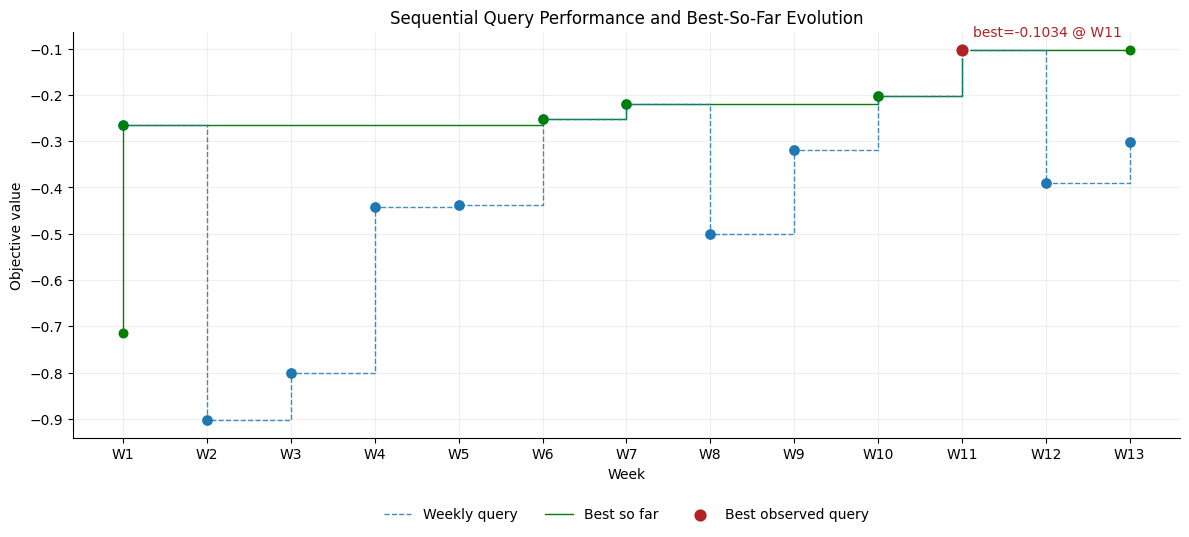

In [8]:
performance, performance_summary = sequential_performance(
    initial_outputs=initial_outputs,
    query_outputs=query_outputs)

display(performance_summary)
display(performance)

plot_sequential_query_performance(
    performance,
    FUNCTION_ID,
    yscale="linear",
    plot_type="bar")

**Performance result.** The incumbent improves from approximately **-0.714265** to **-0.103406**, an absolute gain of about **0.610859**. Five of the 13 evaluations improve the incumbent directly: **Weeks 1, 6, 7, 10 and 11**.

**5.2 - Surrogate robustness**

Leave-one-out validation compares the early RBF model, the global Week 4 Matérn model and the later local Matérn specification. RMSE measures value prediction; Spearman correlation measures whether the surrogate preserves the ranking of better versus worse observations.

In [9]:
predictive_kernels = {
    "RBF_global": rbf_kernel,
    "Matern_52_global": week_4_kernel,
    "Matern_52_local": local_kernel}

surrogate_robustness = kernel_choice_validation(
    inputs,
    outputs,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=RANDOM_SEED)

display(surrogate_robustness)

,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,RBF_global,0.299873,0.923463
1,Matern_52_global,0.314533,0.904078
2,Matern_52_local,0.286944,0.914439


**Interpretation.** This comparison is descriptive: it checks whether the modelling family materially changes out-of-sample error or ranking quality. It does not retrospectively replace the historical search policy with whichever kernel performs best after all observations are known.

**5.3 - Acquisition agreement and record consistency**

In [10]:
acquisition_diagnostic = phase_3_history[[
    "week",
    "EI_UCB_distance",
    "proposal_record_distance",
    "matches_record",
    "improved_incumbent",
]].copy()

display(acquisition_diagnostic)

display(pd.DataFrame([{
    "EI_UCB_exact_coincidences": int(
        (phase_3_history["EI_UCB_distance"] < 1e-10).sum()
    ),
    "EI_queries_matching_record": int(
        phase_3_history["matches_record"].sum()
    ),
    "record_mismatches": int(
        (~phase_3_history["matches_record"]).sum()
    ),
}]))

,week,EI_UCB_distance,proposal_record_distance,matches_record,improved_incumbent
0,6,0.066280,3.177046e-07,True,True
1,7,0.000000,7.365543e-07,True,True
2,8,0.037212,3.745998e-01,False,False
3,9,0.000000,9.212871e-07,True,False
4,10,0.038011,4.056794e-07,True,True
5,11,0.000000,3.740567e-07,True,True
6,12,0.067347,4.579035e-07,True,False
7,13,0.000000,7.531681e-07,True,False


,EI_UCB_exact_coincidences,EI_queries_matching_record,record_mismatches
0,4,7,1


**Interpretation.** EI/UCB distance is a decision diagnostic, not a performance metric: disagreement is expected because the acquisitions express different exploration–exploitation preferences. Proposal/record distance answers a different question—whether the reconstructed selected point is the point that was actually evaluated. The known Week 8 discrepancy should therefore remain visible.

**5.4 - Early-search sensitivity**

The Week 1 RBF-UCB decision is checked against RBF initialisation, UCB $\kappa$, and Cartesian resolution. The generic grid helper is reused here, so no Function-6-specific 5D search code is required.

In [11]:
# RBF initialisation
initialisation_rows = []

for initial_scale in [0.05, 0.10, 0.20, 0.40]:
    kernel = (
        RBF(
            length_scale=initial_scale,
            length_scale_bounds=(1e-5, 1e5),
        )
        + WhiteKernel(noise_level=1e-6)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        normalize_y=True,
        random_state=RANDOM_SEED,
    )
    gp.fit(initial_inputs, initial_outputs)

    initialisation_rows.append({
        "initial_length_scale": initial_scale,
        "fitted_length_scale": float(gp.kernel_.k1.length_scale),
        "log_marginal_likelihood": gp.log_marginal_likelihood_value_,
    })

display(pd.DataFrame(initialisation_rows))

# Historical Week 1 model
week_1_gp = GaussianProcessRegressor(
    kernel=rbf_kernel,
    alpha=1e-10,
    normalize_y=True,
)
week_1_gp.fit(initial_inputs, initial_outputs)

# UCB kappa sensitivity: predict each 25^5 block once
kappas = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
best_by_kappa = {
    kappa: {"score": -np.inf, "candidate": None}
    for kappa in kappas
}

for candidates in original_grid_blocks(
    DIMENSION,
    GRID_RESOLUTION,
):
    mean, std = week_1_gp.predict(candidates, return_std=True)

    for kappa in kappas:
        scores = upper_confidence_bound(
            mean,
            std,
            kappa=kappa,
        )
        idx = int(np.argmax(scores))

        if scores[idx] > best_by_kappa[kappa]["score"]:
            best_by_kappa[kappa] = {
                "score": float(scores[idx]),
                "candidate": candidates[idx].copy(),
            }

historical_week_1, _ = historical_record(FUNCTION_ID, 1)

display(pd.DataFrame([
    {
        "kappa": kappa,
        "candidate": np.round(result["candidate"], 6).tolist(),
        "distance_to_historical_week_1": float(
            np.linalg.norm(result["candidate"] - historical_week_1)
        ),
        "UCB_max": result["score"],
    }
    for kappa, result in best_by_kappa.items()
]))

,initial_length_scale,fitted_length_scale,log_marginal_likelihood
0,0.05,0.050000,-28.378771
1,0.10,0.064292,-28.378771
2,0.20,0.444299,-24.621889
3,0.40,0.444299,-24.621889


,kappa,candidate,distance_to_historical_week_1,UCB_max
0,1.0,"[0.416667, 0.375, 0.5, 0.75, 0.166667]",7.216898e-02,-0.299250
1,1.5,"[0.375, 0.333333, 0.5, 0.75, 0.125]",3.333333e-07,-0.172595
2,2.0,"[0.333333, 0.333333, 0.458333, 0.75, 0.083333]",7.216878e-02,-0.032222
3,2.5,"[0.291667, 0.333333, 0.458333, 0.75, 0.041667]",1.250000e-01,0.120314
4,3.0,"[0.291667, 0.333333, 0.416667, 0.708333, 0.0]",1.767767e-01,0.284667
5,4.0,"[0.208333, 0.291667, 0.416667, 0.75, 0.0]",2.282177e-01,0.639786


In [12]:
# Cartesian-resolution sensitivity
grid_rows = []

for resolution in [10, 15, 20, 25]:
    search = exhaustive_cartesian_search(
        week_1_gp,
        dimension=DIMENSION,
        resolution=resolution,
        kappa=1.5,
        compute_ucb=True)
    
    candidate = search["ucb_point"]

    grid_rows.append({
        "resolution": resolution,
        "n_candidates": search["n_candidates"],
        "candidate": np.round(candidate, 6).tolist(),
        "distance_to_historical_week_1": float(np.linalg.norm(candidate - historical_week_1)),
        "UCB_max": search["ucb_max"]})

display(pd.DataFrame(grid_rows))

,resolution,n_candidates,candidate,distance_to_historical_week_1,UCB_max
0,10,100000,"[0.333333, 0.333333, 0.444444, 0.777778, 0.111...",7.607258e-02,-0.182281
1,15,759375,"[0.357143, 0.357143, 0.5, 0.785714, 0.142857]",4.980135e-02,-0.177203
2,20,3200000,"[0.368421, 0.368421, 0.473684, 0.736842, 0.105...",5.029561e-02,-0.171879
3,25,9765625,"[0.375, 0.333333, 0.5, 0.75, 0.125]",3.333333e-07,-0.172595


**Interpretation.** Exact coordinate equality is not required under nearby $\kappa$ values or coarser discretisations. The relevant robustness question is whether the recommendation remains in the same broad 5D region.

**5.5 - Local decision stability**

Week 11 is used because it produces the final incumbent. The state immediately before Week 11 is reconstructed, then the Matérn starting scale and local-radius multiplier are varied while the Sobol seed, candidate count, EI rule and observed data are held fixed.

In [13]:
# Reconstruct the state immediately before Week 11
pre_week_11_data = load_initial_data(FUNCTION_ID)

for week in range(1, 11):
    point, value = historical_record(FUNCTION_ID, week)
    pre_week_11_data = update_data(
        pre_week_11_data,
        point,
        value)

pre_inputs, pre_outputs = extract(pre_week_11_data)
incumbent_idx = int(np.argmax(pre_outputs))
incumbent_x = pre_inputs[incumbent_idx].copy()
incumbent_y = float(pre_outputs[incumbent_idx])
historical_week_11, _ = historical_record(FUNCTION_ID, 11)

# Matérn initialisation sensitivity
scale_rows = []

for initial_scale in [0.05, 0.10, 0.20, 0.40]:
    candidates, _, _ = local_sobol_candidates(
        incumbent_x,
        LOCAL_RADIUS,
        pre_inputs,
        power=SOBOL_POWER,
        seed=SOBOL_SEED,
        min_distance=0.001)

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(
            length_scale=np.full(DIMENSION, initial_scale),
            length_scale_bounds=(1e-2, 3.0),
            nu=2.5)
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-8, 1e-2)))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        normalize_y=True,
        n_restarts_optimizer=12,
        random_state=RANDOM_SEED)
    
    gp.fit(pre_inputs, pre_outputs)

    mean, std = gp.predict(candidates, return_std=True)
    scores = expected_improvement(
        mean,
        std,
        best=incumbent_y,
        xi=0.001)
    
    candidate = candidates[int(np.argmax(scores))]

    scale_rows.append({
        "initial_scale": initial_scale,
        "fitted_scales": np.round(np.atleast_1d(gp.kernel_.k1.k2.length_scale),5).tolist(),
        "candidate": np.round(candidate, 6).tolist(),
        "distance_to_historical_week_11": float(
            np.linalg.norm(candidate - historical_week_11))})

print("Matérn initialisation sensitivity")
display(pd.DataFrame(scale_rows))

# Radius sensitivity with the historical Week 11 GP
historical_gp = GaussianProcessRegressor(
    kernel=local_kernel,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=12,
    random_state=RANDOM_SEED)

historical_gp.fit(pre_inputs, pre_outputs)

radius_rows = []

for multiplier in [0.50, 0.75, 1.00, 1.25, 1.50]:
    radius = LOCAL_RADIUS * multiplier
    candidates, _, _ = local_sobol_candidates(
        incumbent_x,
        radius,
        pre_inputs,
        power=SOBOL_POWER,
        seed=SOBOL_SEED,
        min_distance=0.001)

    mean, std = historical_gp.predict(candidates, return_std=True)
    scores = expected_improvement(
        mean,
        std,
        best=incumbent_y,
        xi=0.001)
    
    candidate = candidates[int(np.argmax(scores))]

    radius_rows.append({
        "radius_multiplier": multiplier,
        "candidate": np.round(candidate, 6).tolist(),
        "distance_to_incumbent": float(np.linalg.norm(candidate - incumbent_x)),
        "distance_to_historical_week_11": float(np.linalg.norm(candidate - historical_week_11)),
        "EI_max": float(scores.max())})

print("Local-radius sensitivity")
display(pd.DataFrame(radius_rows))

Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Matérn initialisation sensitivity


,initial_scale,fitted_scales,candidate,distance_to_historical_week_11
0,0.05,"[0.6607, 0.71937, 0.81731, 0.9505, 0.95174]","[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]",3.740567e-07
1,0.10,"[0.66071, 0.71937, 0.81731, 0.9505, 0.95174]","[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]",3.740567e-07
2,0.20,"[0.6607, 0.71937, 0.81731, 0.9505, 0.95174]","[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]",3.740567e-07
3,0.40,"[0.6607, 0.71937, 0.81731, 0.9505, 0.95174]","[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]",3.740567e-07


Local-radius sensitivity


,radius_multiplier,candidate,distance_to_incumbent,distance_to_historical_week_11,EI_max
0,0.50,"[0.383383, 0.407509, 0.649238, 0.738382, 0.148...",0.100557,4.631268e-02,0.045166
1,0.75,"[0.363272, 0.39833, 0.652294, 0.719154, 0.138608]",0.117528,2.458847e-02,0.047222
2,1.00,"[0.354065, 0.40333, 0.651952, 0.722302, 0.11659]",0.133504,3.740567e-07,0.047173
3,1.25,"[0.351674, 0.395685, 0.670881, 0.713841, 0.10146]",0.138173,2.688829e-02,0.045406
4,1.50,"[0.378127, 0.406127, 0.636128, 0.745131, 0.115...",0.123501,3.686229e-02,0.045942


**Decision-stability interpretation.** The initial-scale check tests whether GP fitting is driven by an arbitrary starting value; the radius check tests whether the successful Week 11 decision depends on one exact trust-region size. Nearby candidates are sufficient for stability—the maximiser need not be numerically identical after every reasonable perturbation.

<h1 style="color:#0000CD;font-size:19px;">6. Conclusion and limitations</h1>

Function 6 improves the initial incumbent from approximately **-0.714265** to **-0.103406** over 13 sequential evaluations, an absolute gain of about **0.610859**. Five queries improve the incumbent: **Weeks 1, 6, 7, 10 and 11**.

The observed search path has a compact three-phase interpretation:

- **Weeks 1–3 — Cartesian RBF-UCB exploration:** a $25^5$ Cartesian search finds a substantially better region immediately, but further grid-based exploration does not improve it.
- **Weeks 4–5 — Sobol Matérn 5/2-UCB transition:** Week 4 replaces the tensor grid with global Sobol/Matérn UCB; Week 5 immediately localises that same framework and compares EI with UCB.
- **Weeks 6–13 — Local Sobol Matérn-EI:** EI becomes the selected acquisition and produces four additional incumbent improvements, with the best observed point reached in Week 11.

The Week 8 proposal/record discrepancy is preserved explicitly, and all later models use the evaluated historical record. The notebook therefore reports the **best observed configuration under the available budget**, not proof of a global maximum.